In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

rng = np.random.default_rng(seed=42)

BUDGET = 1_000_000
N_SCENARIOS = 10_000
NOISE_SIGMA = 0.02  # return std in "signal doesn't fire" regime

# R5 Manual Trading — Ignith Exchange Allocation Optimizer

**Fee formula (confirmed):** `fee_i = (v_i / 100)² × Budget = w_i² × Budget`

**Budget:** 1,000,000 shells. Unused budget expires worthless — but don't over-allocate past each product's individual optimum (`w_i* = E[r_i] / 2`). The solver handles this automatically.

## Section 1: Parameters — EDIT HERE

Adjust `TIERS` (mu/sigma/p_fire) and `PRODUCTS` (direction/tier) in the cells below. All downstream sections re-run automatically.

In [64]:
# Tier parameters re-calibrated for R5 beauty-contest grading mechanism.
# Wiki: realized_return = clip(anchor + f(crowd_flow), range_lo, range_hi).
# Loud unanimous signals saturate the range bound -> quadratic fees punish over-allocation.
# So mu/sigma/p_fire below represent POST-CROWD realized-return distributions,
# NOT raw signal magnitude (the way P3-historical tiers did).
#
# mu     = expected effective return when signal "fires" in the news direction
# sigma  = std of that return
# p_fire = probability the price moves in the news direction
TIERS: dict[str, dict] = {
    "obvious":    {"mu": 0.50, "sigma": 0.06, "p_fire": 0.90},
    "subtle":        {"mu": 0.22, "sigma": 0.08, "p_fire": 0.75},
    "partial":       {"mu": 0.18, "sigma": 0.06, "p_fire": 0.85},
    "ambiguous": {"mu": 0.25, "sigma": 0.12, "p_fire": 0.65},
    "sulfur":      {"mu": 0.15, "sigma": 0.06, "p_fire": 0.75},
    "pump":       {"mu": 0.18, "sigma": 0.5, "p_fire": 0.75},

    # Legacy P3-historical tiers preserved for reference; not used by current PRODUCTS list.
    "very_strong":  {"mu": 0.55, "sigma": 0.15, "p_fire": 0.75},
    "strong":       {"mu": 0.35, "sigma": 0.12, "p_fire": 0.70},
    "moderate":     {"mu": 0.17, "sigma": 0.07, "p_fire": 0.60},
    "moderate_low": {"mu": 0.05, "sigma": 0.03, "p_fire": 0.50},
}


In [65]:
# direction: +1 = BUY, -1 = SELL
# effective_return = direction * price_move (>= 0 when signal fires correctly)
# Tiers reflect post-crowd realized-return distributions; see TIERS above.
#
# Direction flips vs. naive headline read:
#   - Obsidian Cutlery: SELL -> BUY (supply-shock contrarian; halt tightens supply)
#   - Volcanic Incense: BUY -> SELL (exhausted-pump contrarian; "sudden surge" past tense)
PRODUCTS: list[dict] = [
    {"name": "Scoria Paste",     "direction": -1, "tier": "ambiguous"},
    {"name": "Lava Cakes",       "direction": -1, "tier": "subtle"},
    {"name": "Obsidian Cutlery", "direction": +1, "tier": "obvious"},
    {"name": "Thermalite",       "direction": +1, "tier": "subtle"},
    {"name": "Pyroflex Cell",    "direction": -1, "tier": "partial"},
    {"name": "Magma Ink",        "direction": +1, "tier": "subtle"},
    {"name": "Sulfur Ltd.",      "direction": +1, "tier": "sulfur"},
    {"name": "Phoenix Origin",   "direction": -1, "tier": "obvious"},
    {"name": "Volcanic Incense", "direction": -1, "tier": "pump"},
]
NAMES = [p["name"] for p in PRODUCTS]
N = len(PRODUCTS)  # 9


In [66]:
assert N == 9, f"Expected 9 products, got {N}"
assert all(p["tier"] in TIERS for p in PRODUCTS), "Unknown tier"
assert all(p["direction"] in (+1, -1) for p in PRODUCTS), "Direction must be +1 or -1"

# Display parameter summary
rows = []
for p in PRODUCTS:
    t = TIERS[p["tier"]]
    rows.append({
        "Product": p["name"],
        "Direction": "BUY" if p["direction"] == 1 else "SELL",
        "Tier": p["tier"],
        "μ (%)": f"{t['mu']*100:.0f}%",
        "σ (%)": f"{t['sigma']*100:.0f}%",
        "p_fire": t["p_fire"],
    })
display(pd.DataFrame(rows))
print("✓ Section 1 OK")

,Product,Direction,Tier,μ (%),σ (%),p_fire
0,Scoria Paste,SELL,ambiguous,25%,12%,0.65
1,Lava Cakes,SELL,subtle,22%,8%,0.75
2,Obsidian Cutlery,BUY,obvious,50%,6%,0.90
3,Thermalite,BUY,subtle,22%,8%,0.75
4,Pyroflex Cell,SELL,partial,18%,6%,0.85
5,Magma Ink,BUY,subtle,22%,8%,0.75
6,Sulfur Ltd.,BUY,sulfur,15%,6%,0.75
7,Phoenix Origin,SELL,obvious,50%,6%,0.90
8,Volcanic Incense,SELL,pump,18%,50%,0.75


✓ Section 1 OK


## Section 2: Distribution Visualizer (read-only)

Plots the bimodal jump-drift distribution for each product. The analytic cross-check uses `E[r_i] = p_fire × μ`. The MC uses sampled draws from this mixture.

In [67]:
def sample_effective_returns(n: int) -> np.ndarray:
    """
    Returns (n, N) array of effective returns.
    Effective return = direction * price_move, always >= 0 when signal fires correctly.
    Rows = scenarios, columns = products (in PRODUCTS order).
    """
    out = np.zeros((n, N))
    for j, prod in enumerate(PRODUCTS):
        t = TIERS[prod["tier"]]
        mu, sigma, p_fire = t["mu"], t["sigma"], t["p_fire"]

        fires = rng.random(n) < p_fire
        # Signal regime: abs(N(mu, sigma^2)) — one-sided toward signal
        signal_draws = np.abs(rng.normal(mu, sigma, n))
        # Noise regime: N(0, NOISE_SIGMA^2) — small symmetric noise
        noise_draws = rng.normal(0, NOISE_SIGMA, n)

        out[:, j] = np.where(fires, signal_draws, noise_draws)
    return out

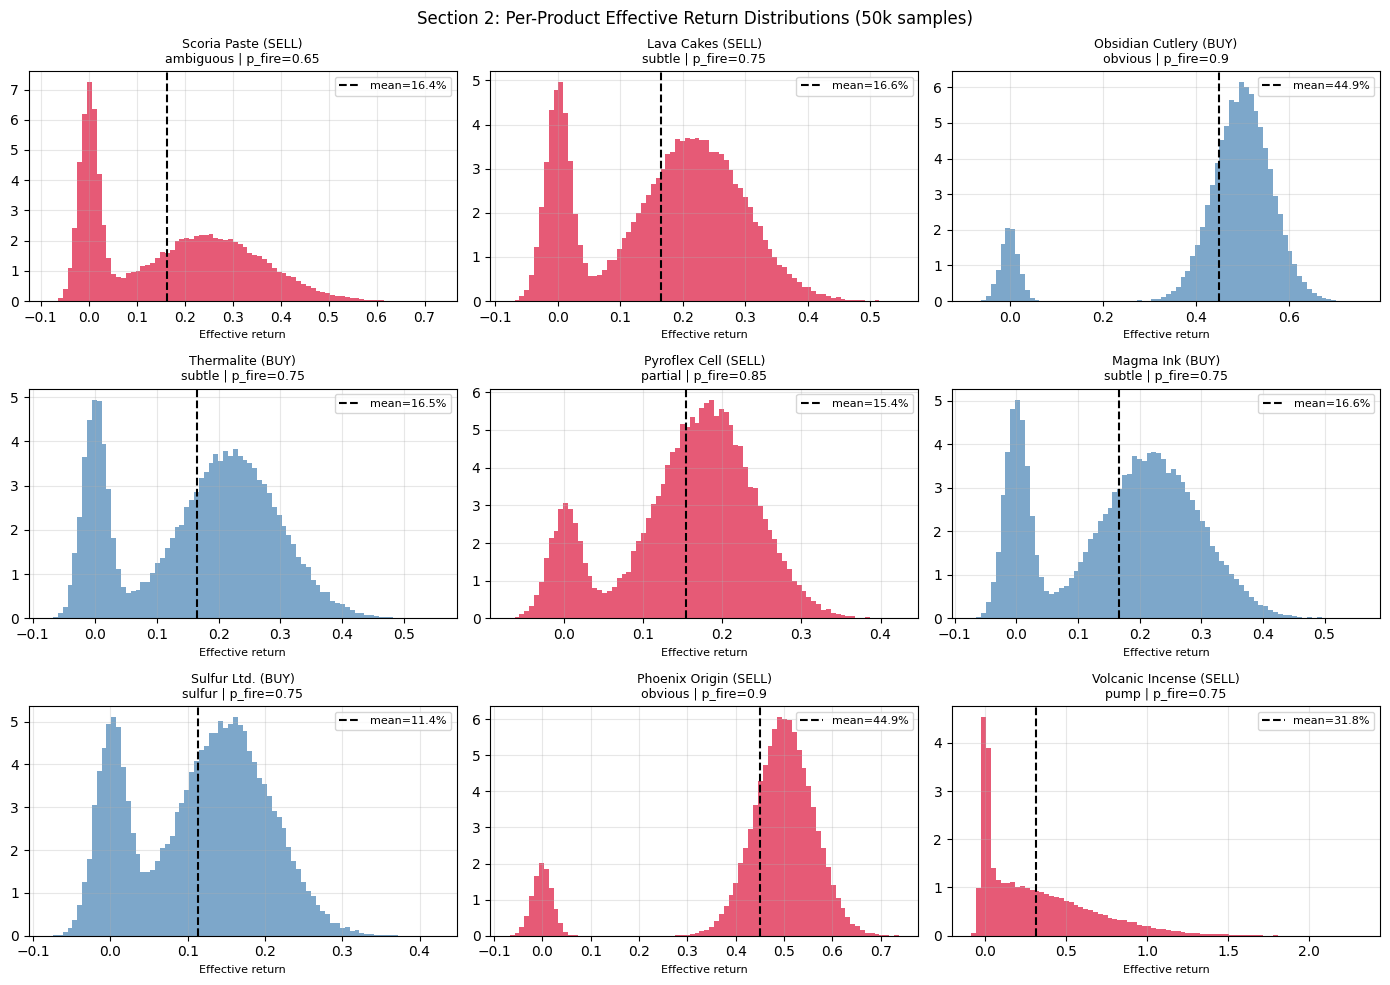

AssertionError: Volcanic Incense: mean=0.318, expected~0.135

In [68]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

preview = sample_effective_returns(50_000)

for j, (ax, prod) in enumerate(zip(axes, PRODUCTS)):
    t = TIERS[prod["tier"]]
    direction_label = "BUY" if prod["direction"] == 1 else "SELL"
    color = "steelblue" if prod["direction"] == 1 else "crimson"

    ax.hist(preview[:, j], bins=80, color=color, alpha=0.7, density=True)
    ax.axvline(preview[:, j].mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"mean={preview[:, j].mean()*100:.1f}%")
    ax.set_title(f"{prod['name']} ({direction_label})\n{prod['tier']} | p_fire={t['p_fire']}", fontsize=9)
    ax.set_xlabel("Effective return", fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Section 2: Per-Product Effective Return Distributions (50k samples)", fontsize=12)
plt.tight_layout()
plt.show()

# Verify means are in reasonable range
for j, prod in enumerate(PRODUCTS):
    t = TIERS[prod["tier"]]
    expected_mean = t["p_fire"] * t["mu"]
    actual_mean = preview[:, j].mean()
    assert abs(actual_mean - expected_mean) < 0.03, \
        f"{prod['name']}: mean={actual_mean:.3f}, expected~{expected_mean:.3f}"

print("✓ Section 2 OK — all distribution means within 3pp of expected")

## Section 3: KKT Solver + Monte Carlo (read-only)

**Analytic** (`w_analytic`): solves the KKT conditions using point-estimate `E[r_i]`. This is the theoretically optimal allocation under the expected-PnL objective.

**Monte Carlo** (`w_mc`): averages optimal allocations across 10,000 sampled scenarios. Useful as a robustness check — where MC and analytic diverge, the signal has high magnitude uncertainty.

In [ ]:
def solve_kkt(r: np.ndarray) -> np.ndarray:
    """
    Solves: max sum(r_i*w_i - w_i^2)  s.t.  sum(w_i) <= 1, w_i >= 0
    Unconstrained optimum: w_i* = r_i / 2.
    If sum(w_i*) <= 1: use it directly (budget constraint not active).
    If sum(w_i*) > 1:  activate budget constraint and solve with brentq.
    """
    w_unc = np.maximum(0.0, r / 2)
    if w_unc.sum() <= 1.0:
        return w_unc  # leave unallocated budget to expire — better than over-paying fees

    # Budget constraint active: find lambda s.t. sum(max(0, (r-lam)/2)) = 1
    def total_weight(lam: float) -> float:
        return float(np.sum(np.maximum(0.0, (r - lam) / 2)))

    lam_lo = r.min() - 10.0
    lam_hi = r.max() + 1e-9
    lam = brentq(lambda lam: total_weight(lam) - 1.0, lam_lo, lam_hi, xtol=1e-12)
    w = np.maximum(0.0, (r - lam) / 2)
    w /= w.sum()  # renormalize against floating-point drift
    return w

In [ ]:
# Check 1: uniform returns, sum(unc) = 9×0.15 = 1.35 > 1 → budget active → uniform allocation
r_uniform = np.full(N, 0.30)
w_uniform = solve_kkt(r_uniform)
assert np.allclose(w_uniform, 1/N, atol=1e-6), f"Uniform check failed: {w_uniform}"

# Check 2: dominant product, sum(unc) = 0.40+0.40 = 0.80 ≤ 1 → budget NOT active, sum < 1
r_dominant = np.full(N, 0.10)
r_dominant[0] = 0.80
w_dominant = solve_kkt(r_dominant)
assert w_dominant[0] > 0.30, f"Dominant product check failed: w[0]={w_dominant[0]:.3f}"
assert w_dominant.sum() <= 1.0 + 1e-9, f"Weights exceed 1: {w_dominant.sum():.6f}"

# Check 3: all negative → unconstrained optima are 0, nothing allocated
r_negative = np.full(N, -0.10)
w_negative = solve_kkt(r_negative)
assert w_negative.sum() < 1e-9, f"Negative returns: expected 0 allocation, got {w_negative.sum():.6f}"

print("✓ KKT solver OK")

In [ ]:
r_analytic = np.array([
    TIERS[p["tier"]]["p_fire"] * TIERS[p["tier"]]["mu"]
    for p in PRODUCTS
])

w_analytic = solve_kkt(r_analytic)

print("Analytic allocation (point-estimate):")
for name, w, r in zip(NAMES, w_analytic, r_analytic):
    print(f"  {name:<22} E[r]={r*100:5.1f}%  →  w={w*100:5.1f}%")
print(f"\n  Total allocation: {w_analytic.sum()*100:.2f}%")

In [ ]:
# Reset RNG for reproducibility before the main run
rng = np.random.default_rng(seed=42)
scenarios = sample_effective_returns(N_SCENARIOS)  # shape (N_SCENARIOS, N)

# Solve KKT for every scenario — vectorized over rows
allocations = np.zeros((N_SCENARIOS, N))
for k in range(N_SCENARIOS):
    allocations[k] = solve_kkt(scenarios[k])

w_mc = allocations.mean(axis=0)  # shape (N,)

assert w_mc.sum() <= 1.0 + 1e-9, f"MC mean weights exceed 1: {w_mc.sum():.6f}"
print(f"✓ Monte Carlo complete ({N_SCENARIOS:,} scenarios)")
print(f"  Allocated: {w_mc.sum()*100:.2f}%  |  Unallocated: {(1 - w_mc.sum())*100:.2f}%")

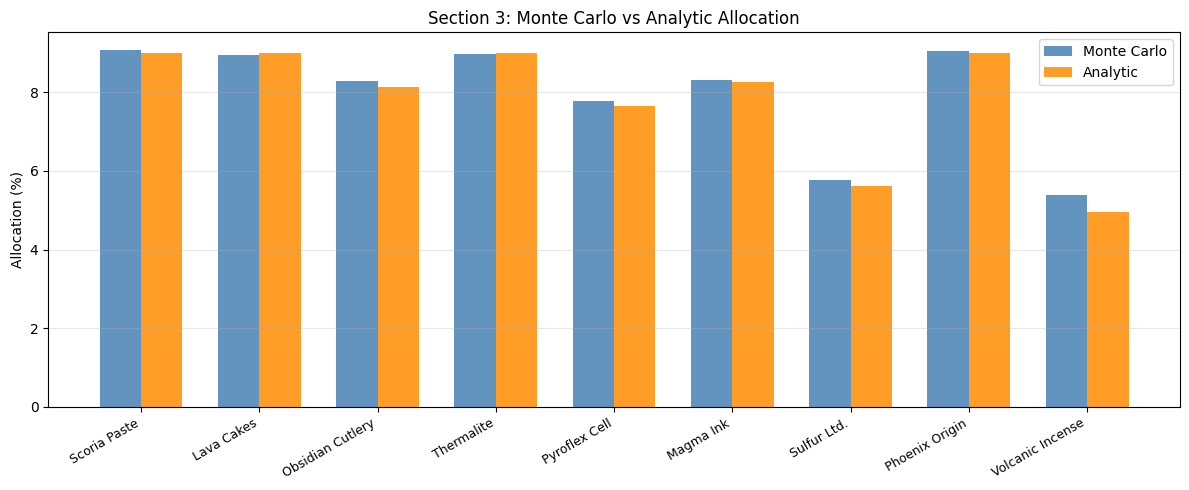

✓ obvious_consensus tier: MC and analytic agree within 5pp


In [69]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(N)
width = 0.35

bars_mc = ax.bar(x - width/2, w_mc * 100, width, label="Monte Carlo", color="steelblue", alpha=0.85)
bars_an = ax.bar(x + width/2, w_analytic * 100, width, label="Analytic", color="darkorange", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(NAMES, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Allocation (%)")
ax.set_title("Section 3: Monte Carlo vs Analytic Allocation")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Cross-check: obvious_consensus tier products should agree within 5pp (highest-confidence signals)
for j, prod in enumerate(PRODUCTS):
    if prod["tier"] == "obvious_consensus":
        diff = abs(w_mc[j] - w_analytic[j]) * 100
        assert diff < 5.0, \
            f"{prod['name']}: MC={w_mc[j]*100:.1f}% vs analytic={w_analytic[j]*100:.1f}% — diff={diff:.1f}pp > 5pp"

print("✓ obvious_consensus tier: MC and analytic agree within 5pp")


## Section 4: Sensitivity + Final Submission Table (read-only)

Run this section last. `w_mc` is the primary allocation recommendation. The sensitivity heatmap shows the top-3 allocations across a range of `p_fire` assumptions.

In [70]:
# Derive top-3 from analytic allocations — stays correct if PRODUCTS is reordered
top3_idx = list(np.argsort(-w_analytic)[:3])
top3_names = [NAMES[i] for i in top3_idx]
p_fire_grid = np.arange(0.40, 0.96, 0.05)
sensitivity = np.zeros((len(p_fire_grid), len(top3_idx)))

# Sweep p_fire on the dominant beauty-contest tier (most products + highest-confidence)
SWEEP_TIERS = ("obvious", "partial")

for i, pf_val in enumerate(p_fire_grid):
    modified_tiers = {k: dict(v) for k, v in TIERS.items()}
    for tier_name in SWEEP_TIERS:
        modified_tiers[tier_name]["p_fire"] = pf_val

    r_mod = np.array([
        modified_tiers[p["tier"]]["p_fire"] * modified_tiers[p["tier"]]["mu"]
        for p in PRODUCTS
    ])
    w_mod = solve_kkt(r_mod)
    for col, idx in enumerate(top3_idx):
        sensitivity[i, col] = w_mod[idx] * 100

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(sensitivity.T, aspect="auto", origin="lower",
               extent=[p_fire_grid[0], p_fire_grid[-1], -0.5, len(top3_idx)-0.5],
               cmap="RdYlBu_r")
plt.colorbar(im, ax=ax, label="Allocation (%)")
ax.set_yticks(range(len(top3_idx)))
ax.set_yticklabels([NAMES[idx] for idx in top3_idx])
ax.set_xlabel(f"p_fire (applied to {' + '.join(SWEEP_TIERS)} tiers)")
ax.set_title("Section 4: Sensitivity — top-3 allocations vs p_fire assumption")
plt.tight_layout()
plt.show()


KeyError: 'obvious_consensus'

In [50]:
fee_per_product = (w_mc ** 2) * BUDGET  # quadratic fee per product
total_fee = fee_per_product.sum()

# Expected gross PnL per product (analytic estimate)
expected_gross = np.array([
    w_mc[j] * TIERS[PRODUCTS[j]["tier"]]["p_fire"] * TIERS[PRODUCTS[j]["tier"]]["mu"] * BUDGET
    for j in range(N)
])
expected_net = expected_gross - fee_per_product

print(f"Total expected fee drag: {total_fee:,.0f} shells ({total_fee/BUDGET*100:.1f}% of budget)")
print(f"Total expected gross PnL: {expected_gross.sum():,.0f} shells")
print(f"Total expected net PnL: {expected_net.sum():,.0f} shells\n")

assert total_fee < BUDGET * 0.30, \
    f"Fee drag {total_fee/BUDGET*100:.1f}% exceeds 30% — check allocations are not over-concentrated"
print("✓ Fee check passed")

Total expected fee drag: 58,506 shells (5.9% of budget)
Total expected gross PnL: 115,754 shells
Total expected net PnL: 57,248 shells

✓ Fee check passed


In [51]:
rows = []
for j, prod in enumerate(PRODUCTS):
    t = TIERS[prod["tier"]]
    rows.append({
        "Product": prod["name"],
        "Direction": "BUY" if prod["direction"] == 1 else "SELL",
        "Allocation (%)": f"{w_mc[j]*100:.1f}%",
        "Volume (shells)": f"{w_mc[j]*BUDGET:,.0f}",
        "Fee (shells)": f"{fee_per_product[j]:,.0f}",
        "E[Gross PnL]": f"{expected_gross[j]:,.0f}",
        "E[Net PnL]": f"{expected_net[j]:,.0f}",
        "Tier": prod["tier"],
    })

df_final = pd.DataFrame(rows)
display(df_final)

total_alloc = w_mc.sum() * 100
unallocated = (1 - w_mc.sum()) * 100
assert total_alloc <= 100.0 + 0.5, f"Total allocation {total_alloc:.2f}% exceeds 100%"

print(f"\nTotal allocated: {total_alloc:.2f}%  |  Unallocated (expires): {unallocated:.2f}%")
print(f"Total fee: {total_fee:,.0f} shells ({total_fee/BUDGET*100:.2f}%)")
print(f"Total E[Net PnL]: {expected_net.sum():,.0f} shells")
print("\n✓ Section 4 complete — ready to submit")

,Product,Direction,Allocation (%),Volume (shells),Fee (shells),E[Gross PnL],E[Net PnL],Tier
0,Scoria Paste,BUY,9.1%,"90,674","8,222","16,321","8,100",obvious_consensus
1,Lava Cakes,SELL,8.9%,"89,435","7,999","16,098","8,100",obvious_consensus
2,Obsidian Cutlery,BUY,8.3%,"82,879","6,869","13,468","6,599",ambiguous_contrarian
3,Thermalite,BUY,9.0%,"89,812","8,066","16,166","8,100",obvious_consensus
4,Pyroflex Cell,SELL,7.8%,"77,799","6,053","11,903","5,851",partial_priced
5,Magma Ink,BUY,8.3%,"83,112","6,908","13,714","6,806",subtle_signal
6,Sulfur Ltd.,BUY,5.8%,"57,719","3,331","6,493","3,162",sulfur_indirect
7,Phoenix Origin,SELL,9.0%,"90,356","8,164","16,264","8,100",obvious_consensus
8,Volcanic Incense,SELL,5.4%,"53,800","2,894","5,326","2,432",exhausted_pump



Total allocated: 71.56%  |  Unallocated (expires): 28.44%
Total fee: 58,506 shells (5.85%)
Total E[Net PnL]: 57,248 shells

✓ Section 4 complete — ready to submit
